# Q6 - Backtesting: Composite Signal Strategy

This notebook implements and evaluates a composite signal strategy across Copper, Zinc, and Crude Oil.

The strategy combines three signals into a single position decision:
1. Price vs long-term SMA (MA200)
2. RSI momentum
3. Fast SMA vs medium SMA cross

Each signal votes -1, 0, or +1. The average determines the position.

In [11]:
import sys

sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from app.database import get_connection, get_indicators
from app.backtest import (
    run_backtest,
    compute_metrics,
)
from app.config import COMMODITIES

## 1. Strategy Design

### Signals

| Signal | Logic | Long (+1) | Short (-1) | Flat (0) |
|--------|-------|-----------|------------|----------|
| Price vs MA200 | Trend filter | Price > MA200 | Price < MA200 | Price = MA200 |
| RSI | Momentum | RSI < 30 (oversold) | RSI > 70 (overbought) | 30 ≤ RSI ≤ 70 |
| MA20 vs MA50 | SMA cross | MA20 > MA50 | MA20 < MA50 | Equal |

### Position Rule

Average of all three signals:
- Average > +0.5 → **Long**
- Otherwise → **Flat**

### Assumptions
- Daily settlement prices - no intraday execution
- Position is set at close of signal day, return realised next day
- No transaction costs or slippage
- Only long positions are allowed

## 2. Load Data

In [12]:
conn = get_connection()

dfs = {}
for commodity in COMMODITIES:
    data = get_indicators(conn, commodity)
    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    dfs[commodity] = df

conn.close()
print("Loaded:", {k: len(v) for k, v in dfs.items()})

Loaded: {'copper': 523, 'zinc': 523, 'crude_oil': 523}


## 3. Run Backtest — All Commodities

In [13]:
results = {}
metrics = {}

for commodity, df in dfs.items():
    result = run_backtest(df)
    results[commodity] = result
    metrics[commodity] = compute_metrics(result)

metrics_df = pd.DataFrame(metrics).T
metrics_df

/Users/daniildubinin/Documents/HT/OilDesk-Intern-Assessment/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,total_return_pct,annualised_return_pct,annualised_vol_pct,sharpe_ratio,max_drawdown_pct,win_rate_pct,n_trades,n_days
copper,10.18,4.79,12.21,0.393,-21.21,53.71,30.0,522.0
zinc,14.49,6.75,13.63,0.495,-11.35,56.57,21.0,522.0
crude_oil,26.54,12.08,20.93,0.577,-19.01,60.26,32.0,520.0


## 4. Cumulative PnL & Drawdown — Strategy vs Buy & Hold

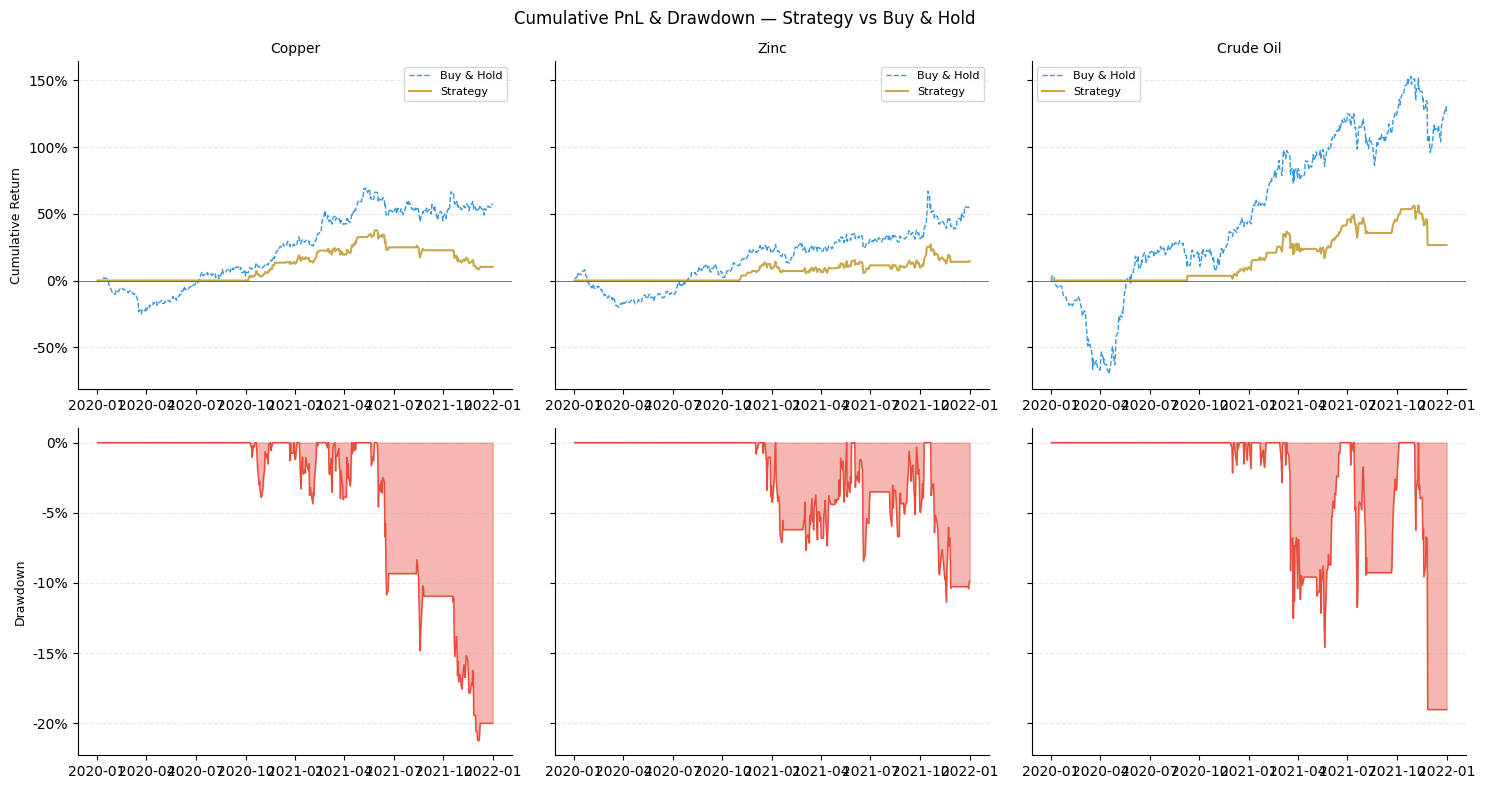

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey="row")

LABELS = {"copper": "Copper", "zinc": "Zinc", "crude_oil": "Crude Oil"}

for i, commodity in enumerate(COMMODITIES):
    result = results[commodity].dropna(subset=["cumulative_return"])

    # PnL row
    ax_pnl = axes[0][i]
    ax_pnl.plot(
        result["date"],
        result["cumulative_return"] * 100,
        color="#3498db",
        linewidth=1,
        linestyle="--",
        label="Buy & Hold",
    )
    ax_pnl.plot(
        result["date"],
        result["cumulative_strategy_return"] * 100,
        color="#c8a84b",
        linewidth=1.5,
        label="Strategy",
    )
    ax_pnl.axhline(0, color="#444", linewidth=0.5)
    ax_pnl.set_title(LABELS[commodity], fontsize=10)
    ax_pnl.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax_pnl.legend(fontsize=8)
    ax_pnl.spines[["top", "right"]].set_visible(False)
    ax_pnl.grid(axis="y", linestyle="--", alpha=0.3)

    # Drawdown row
    ax_dd = axes[1][i]
    ax_dd.fill_between(
        result["date"], result["drawdown"] * 100, 0, color="#e74c3c", alpha=0.4
    )
    ax_dd.plot(result["date"], result["drawdown"] * 100, color="#e74c3c", linewidth=1)
    ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax_dd.spines[["top", "right"]].set_visible(False)
    ax_dd.grid(axis="y", linestyle="--", alpha=0.3)

axes[0][0].set_ylabel("Cumulative Return", fontsize=9)
axes[1][0].set_ylabel("Drawdown", fontsize=9)

fig.suptitle("Cumulative PnL & Drawdown — Strategy vs Buy & Hold", fontsize=12)
fig.tight_layout()
plt.show()

## 5. Performance Commentary

The composite signal strategy generates positive returns across all three commodities over 2020-2021, with Crude Oil performing best at +26.5% total return and a Sharpe ratio of 0.577.

**Results summary**: Crude Oil benefits most from the strategy, likely because its trend was the clearest and most sustained over the period. Zinc shows the most consistent risk-adjusted performance with the lowest max drawdown at -11.4%. Copper underperforms the other two but still delivers a positive Sharpe of 0.393.

**Signal conflict**: in the continuing uptrend, Signal 1 (price vs MA200) and Signal 3 (MA20 vs MA50) consistently vote long. However Signal 2 (RSI) frequently votes against when markets become overbought. This creates enough disagreement to push the composite average below the 0.5 threshold, leaving the strategy flat during some periods of strong upward momentum — which partly explains why all three commodities underperform buy and hold. Solutions to this could be probably add more decorrelated signals to our majority voting strategy.

**Threshold sensitivity**: at threshold 0.5 the strategy requires the majority of signals in agreement before entering a position. This is intentional — it reduces false signals in ranging markets, but it also reduces exposure in a strong trend. The threshold is a key parameter that would normally be optimised on a training set before being validated on unseen data.

**Data limitations**: the dataset covers only two years (2020-2021), which is insufficient for robust strategy evaluation. A proper backtest would require significantly more data covering different market regimes: trending, mean-reverting, and ranging. Additionally, the 200-day warmup period required by the slow moving average means the strategy produces no signals for the first 200 trading days, leaving only around 320 active days per commodity further limiting the statistical significance of the results.

**What a proper process would look like**: with more data, the correct approach would be to split the dataset into a training period and a validation period, optimise the signal threshold and indicator lookback periods on the training set only, and then evaluate the strategy on the unseen validation period. Optimising on the full dataset, as done here, risks overfitting to the specific conditions of 2020-2021.